# Icescopy counts to INP per litre of air with INP-toolkit

Step-by-step analysis of the M1 base-rerun dataset, from freezing counts to INP concentrations per litre of air.

In [1]:
from dataclasses import asdict
from pathlib import Path
import csv
import hashlib
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "inptk-matplotlib"))

# Use this checkout when launched from the project or its notebook folder.
# Otherwise use an installed inptk package.
project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/inptk").is_dir()),
    None,
)
if project_root is not None:
    sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import inptk

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.max_columns = 12
print(f"INP-toolkit {inptk.__version__}: {inptk.__file__}")

Matplotlib is building the font cache; this may take a moment.


INP-toolkit 0.2.0: /Users/C832577250/Project/inptk/src/inptk/__init__.py


## 1. Choose the input and settings

`sample_map` groups `Sample_0` through `Sample_4` under the original sample
`CRG_M1`. Each measurement retains its own dilution and counts.

Use a 0.25 °C grid with `latest` and zero tolerance. `DECREASE_POLICY` selects
final cumulative points during cooling: `stop_at_decrease` ends at the first
decrease; `skip_decreases` omits lower points and allows later recovery to the
previous maximum. Neither changes calculated values or error widths.

MLE limits use measurement names. `drop_rows` excludes observations warmer than
the specified limits without removing their accumulated frozen baseline.
The action weights retain this example's chosen rule: 15 actions halve a
measurement's contribution. These are analysis choices, not contamination
measurements. Both the OLAF-style binomial errors and MLE errors use corrected
counts here; neither separately propagates the water blank's own uncertainty.

In [2]:
DATA_PATH = Path("/Volumes/Hailstone Data/demo (M1) 08.12.25 base rerun/freeze_count_timeseries.csv")
OLAF_REFERENCE_PATH = Path(
    "/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun/"
    "INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv"
)
RUN_ID = "M1-base-rerun"
SAMPLE_MAP = {f"Sample_{i}": "CRG_M1" for i in range(5)}
PLOT_SAMPLE_ID = "CRG_M1"
PLOT_CYCLE_ID = "0"
TEMPERATURE_STEP_C = 0.25
TEMPERATURE_METHOD = "latest"
TEMPERATURE_TOLERANCE_C = 0.0
DECREASE_POLICY = "stop_at_decrease"  # Or "skip_decreases" to allow recovery.
TEMPERATURE_XLIM = (-30, -5)  # Temperature increases from left to right.

automatic_method = inptk.Stitch(min_unfrozen=3)
mle_method = inptk.MLE(
    temperature_eligibility_C={
        "Sample_1": -10, "Sample_2": -15,
        "Sample_3": -20, "Sample_4": -25,
    },
    mask_mode="drop_rows",
    action_counts={
        "Sample_0": 0, "Sample_1": 1, "Sample_2": 2,
        "Sample_3": 3, "Sample_4": 4,
    },
    action_weight_half_life=15,
    confidence_drop=1.920729410347062,
)

# Optional manual alternative: supply four switching temperatures, warm to cold.
# No temperatures are chosen for you, and manual stitching never raises decreases.
MANUAL_SWITCH_TEMPERATURES_C = None

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Mount the data drive or update DATA_PATH: {DATA_PATH}")

## 2. Inspect the export and handle rows with no droplets

This file already contains counts adjusted by Icescopy's water-blank correction.
Its remaining total is `32 − water blank correction count` for every dilution.
**Do not subtract that column again.** No additional blank-spectrum subtraction
is applied in this notebook.

At the cold end, 176 timestamps have zero total and zero frozen droplets in all
five measurements. A frozen fraction cannot be calculated with a zero denominator.
The old numerical routine silently excluded these rows; the current importer
rejects them. Below we explicitly report and exclude them **in memory**, keep the
excluded rows available for inspection, and leave the source CSV untouched.

The header is read separately so the filtered input keeps its original volume
and dilution metadata. No physical metadata is invented or replaced.

In [3]:
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
preamble, header_rows = {}, {}
with DATA_PATH.open(encoding="utf-8") as stream:
    for line in stream:
        if not line.startswith("#"):
            break
        body = line[1:].strip()
        fields = next(csv.reader([body]))
        if len(fields) > 1:
            header_rows[fields[0]] = fields[1:]
        elif ":" in body:
            key, value = body.split(":", 1)
            preamble[key.strip()] = value.strip()

source_metadata = pd.DataFrame(header_rows)
source_metadata = source_metadata.mask(source_metadata.isin(["", "nan"]))
source_metadata["sample_id"] = source_metadata["sample_name"]
source_metadata["well_volume_uL"] = float(preamble["well_volume_uL"])
display(source_metadata[[
    "sample_id", "sample_long_name", "dilution", "well_volume_uL",
    "air_volume_L", "suspension_volume_mL", "filter_fraction_used",
]])

raw_export = pd.read_csv(DATA_PATH, comment="#", dtype={"cycle": str})
total_columns = [c for c in raw_export if c.endswith(" number total")]
frozen_columns = [c for c in raw_export if c.endswith(" number frozen")]
empty_rows = raw_export[total_columns].eq(0).all(axis=1)
if (raw_export[total_columns].le(0).any(axis=1) & ~empty_rows).any():
    raise ValueError("Some measurements have no droplets while others remain: review these rows separately")
if raw_export.loc[empty_rows, frozen_columns].ne(0).any().any():
    raise ValueError("A zero-total row reports frozen droplets; review the source")
excluded_rows = raw_export.loc[empty_rows].copy()
input_rows = raw_export.loc[~empty_rows].copy()
blank_count = raw_export["water blank correction count"]
print(f"Input timestamps: {len(raw_export):,}; excluded zero-total timestamps: {len(excluded_rows):,}")
print(f"Retained timestamps: {len(input_rows):,}; cycles: {input_rows['cycle'].unique().tolist()}")
print(f"Exported blank count: {blank_count.min()} to {blank_count.max()}; no further blank subtraction")
if not excluded_rows.empty:
    display(excluded_rows[["timestamp", "temperature_C", "water blank correction count"]].iloc[[0, -1]])

,sample_id,sample_long_name,dilution,well_volume_uL,air_volume_L,suspension_volume_mL,filter_fraction_used
0,Sample_0,CRG_M1_1,1,50.0,17829.1,10,1
1,Sample_1,CRG_M1_13,13,50.0,17829.1,10,1
2,Sample_2,CRG_M1_169,169,50.0,17829.1,10,1
3,Sample_3,CRG_M1_2197,2197.0,50.0,17829.1,10,1
4,Sample_4,CRG_M1_28561,28561,50.0,17829.1,10,1


Input timestamps: 8,881; excluded zero-total timestamps: 176
Retained timestamps: 8,705; cycles: ['0']
Exported blank count: 0 to 32; no further blank subtraction


,timestamp,temperature_C,water blank correction count
8705,2026-04-22T15:50:51.980,-28.667,32
8880,2026-04-22T15:53:47.980,-29.723,32


In [4]:
imported = inptk.read_icescopy(
    input_rows, metadata=source_metadata, sample_map=SAMPLE_MAP, run_id=RUN_ID,
)
preparation = {
    "operation": "exclude_zero_droplet_timestamps",
    "rows_excluded": len(excluded_rows),
    "reason": "All dilution measurements have zero total and zero frozen droplets",
    "additional_blank_subtraction": False,
}
# Keep the original path and preparation record even though import used a DataFrame.
experiment = inptk.Experiment(
    counts=inptk.CountsTable(imported.counts.to_dataframe(), history=[preparation]),
    samples=imported.samples,
    measurements=imported.measurements,
    source={"format": "icescopy", "path": str(DATA_PATH), "sha256": source_sha256},
)
raw_counts = experiment.counts.to_dataframe()
raw_counts["fraction_frozen"] = raw_counts.n_frozen / raw_counts.n_total
display(raw_counts.groupby(["sample_id", "run_id", "cycle_id", "measurement_id"], sort=False).size().rename("observation_rows").to_frame())

# Selection affects only the plots, not calculation or saved tables.
plot_selection = dict(sample_id=PLOT_SAMPLE_ID, run_id=RUN_ID, cycle_id=PLOT_CYCLE_ID)
selected_counts = experiment.counts.select(**plot_selection).to_dataframe()
if selected_counts.empty:
    raise ValueError("The requested plot sample/run/cycle is absent; inspect the groups above")
selected_counts["fraction_frozen"] = selected_counts.n_frozen / selected_counts.n_total
print(f"Plot selection: {plot_selection}")

observation_rows
sample_id run_id        cycle_id measurement_id                  
CRG_M1    M1-base-rerun 0        Sample_0                    8705
                                 Sample_1                    8705
                                 Sample_2                    8705
                                 Sample_3                    8705
                                 Sample_4                    8705

Plot selection: {'sample_id': 'CRG_M1', 'run_id': 'M1-base-rerun', 'cycle_id': '0'}


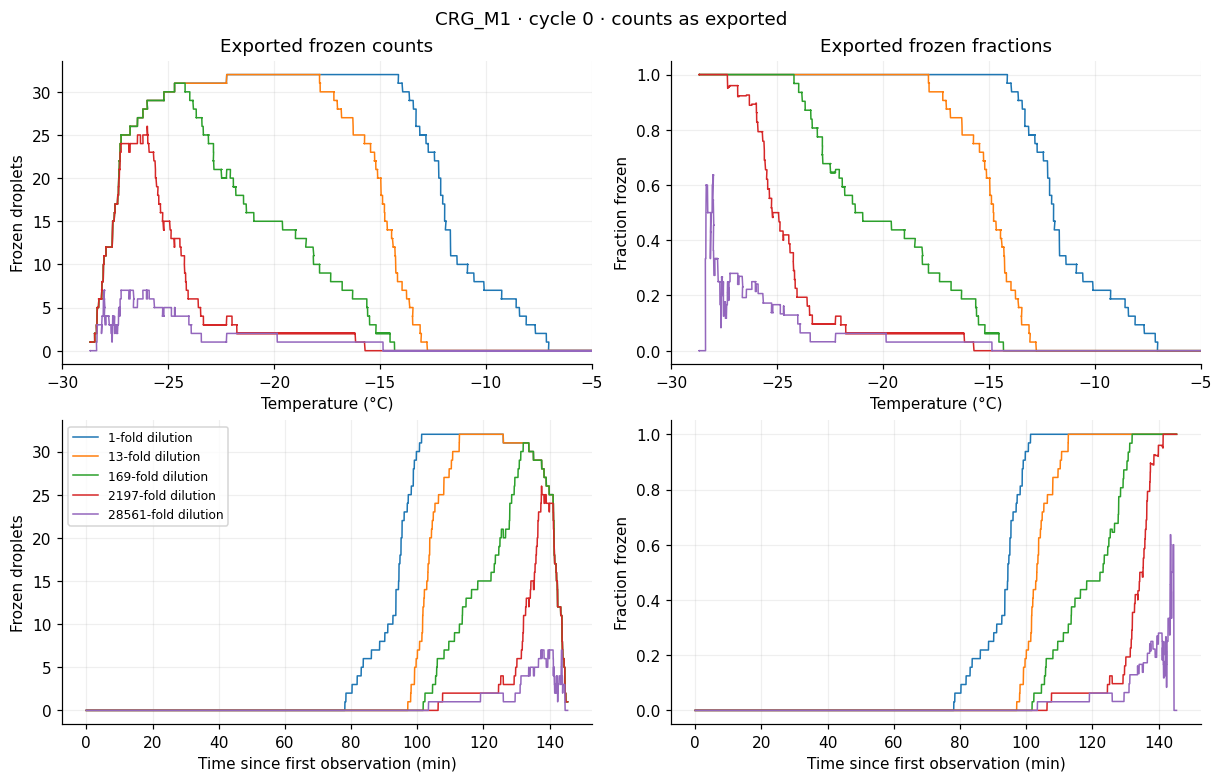

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout="constrained")
for measurement_id, frame in selected_counts.groupby("measurement_id", sort=False):
    dilution = experiment.measurements[measurement_id].dilution
    label = f"{dilution:g}-fold dilution"
    frame = frame.sort_values("time_s")
    axes[0, 0].plot(frame.temperature_C, frame.n_frozen, lw=1, label=label)
    axes[0, 1].plot(frame.temperature_C, frame.fraction_frozen, lw=1, label=label)
    axes[1, 0].plot(frame.time_s / 60, frame.n_frozen, lw=1, label=label)
    axes[1, 1].plot(frame.time_s / 60, frame.fraction_frozen, lw=1, label=label)
axes[0, 0].set(title="Exported frozen counts", xlabel="Temperature (°C)", ylabel="Frozen droplets", xlim=TEMPERATURE_XLIM)
axes[0, 1].set(title="Exported frozen fractions", xlabel="Temperature (°C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
axes[1, 0].set(xlabel="Time since first observation (min)", ylabel="Frozen droplets")
axes[1, 1].set(xlabel="Time since first observation (min)", ylabel="Fraction frozen")
for ax in axes.flat:
    ax.grid(alpha=0.2)
axes[1, 0].legend(fontsize=8, loc="upper left")
fig.suptitle(f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · counts as exported")
plt.show()

## 3. Calculate frozen fractions on the temperature grid

`frozen_fraction()` processes each measurement and cycle separately. `latest`
with zero tolerance selects the last observation at or warmer than each target.
Decreases in the supplied fractions remain visible.

Frozen-fraction rows: 985; grid spacing: 0.25 °C


,sample_id,cycle_id,measurement_id,temperature_C,n_total,n_frozen,fraction_frozen
0,CRG_M1,0,Sample_0,20.50,32.0,0.0,0.0
1,CRG_M1,0,Sample_0,20.25,32.0,0.0,0.0
2,CRG_M1,0,Sample_0,20.00,32.0,0.0,0.0
3,CRG_M1,0,Sample_0,19.75,32.0,0.0,0.0
4,CRG_M1,0,Sample_0,19.50,32.0,0.0,0.0


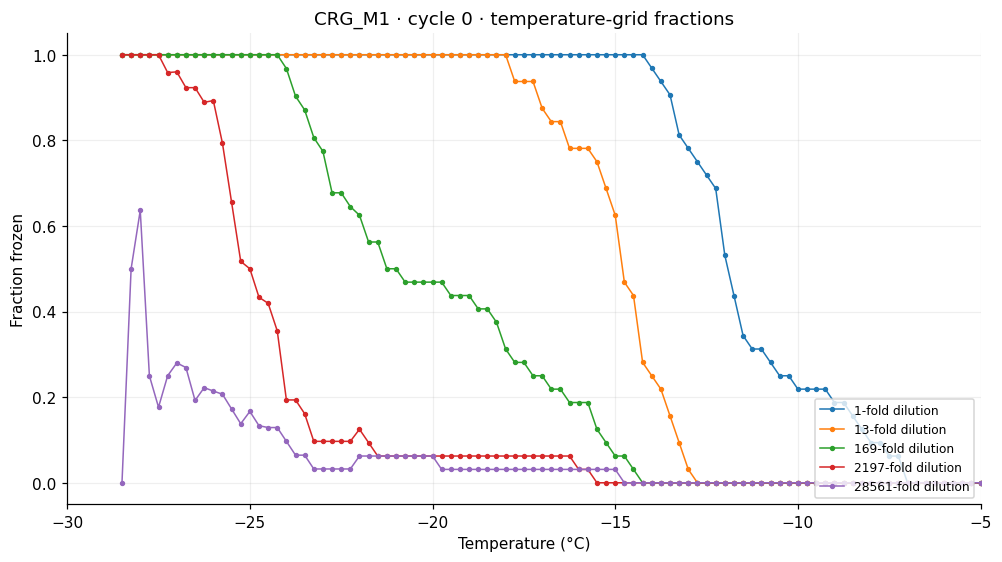

In [6]:
fractions = inptk.frozen_fraction(
    experiment.counts,
    step_C=TEMPERATURE_STEP_C,
    temperature_method=TEMPERATURE_METHOD,
    temperature_tolerance_C=TEMPERATURE_TOLERANCE_C,
)
fraction_df = fractions.to_dataframe()
print(f"Frozen-fraction rows: {len(fraction_df):,}; grid spacing: {TEMPERATURE_STEP_C} °C")
display(fraction_df[["sample_id", "cycle_id", "measurement_id", "temperature_C", "n_total", "n_frozen", "fraction_frozen"]].head())

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for measurement_id, frame in fractions.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False):
    frame = frame.sort_values("temperature_C", ascending=False)
    dilution = experiment.measurements[measurement_id].dilution
    ax.plot(frame.temperature_C, frame.fraction_frozen, "o-", ms=2.5, lw=1, label=f"{dilution:g}-fold dilution")
ax.set(title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · temperature-grid fractions", xlabel="Temperature (°C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.2)
plt.show()

## 4. Calculate each dilution's concentration

`cumulative_spectrum()` converts frozen fractions to INP per mL of original
suspension, already accounting for the droplet volume and dilution factor.
`convert_concentration()` then applies the shared sample volumes to express
the result per litre of sampled air. Do not multiply by dilution a second time.

The new tables use `concentration`. `lower_error` and `upper_error` are distances
below and above that estimate, not the endpoints of the interval. Different
methods calculate these intervals differently; they do not describe variability
across repeated freezing cycles.

In [7]:
individual_suspension = inptk.cumulative_spectrum(fractions, experiment=experiment)
individual_air = inptk.convert_concentration(
    individual_suspension, experiment.samples, basis="sampled_air",
)
sample = experiment.samples[PLOT_SAMPLE_ID]
print("Sample metadata:", asdict(sample))
print(f"Suspension-to-air multiplier: {sample.factor_for('sampled_air'):.10g}")
display(individual_air.select(**plot_selection).to_dataframe()[[
    "measurement_id", "temperature_C", "concentration", "lower_error", "upper_error", "unit",
]].head())

Sample metadata: {'sample_id': 'CRG_M1', 'sample_name': '', 'sample_type': 'air', 'air_volume_L': 17829.1, 'suspension_volume_mL': 10.0, 'filter_fraction_used': 1.0, 'dry_mass_g': None}
Suspension-to-air multiplier: 0.0005608808072


,measurement_id,temperature_C,concentration,lower_error,upper_error,unit
0,Sample_0,20.50,-0.0,0.0,0.001202,INP_per_L_air
1,Sample_0,20.25,-0.0,0.0,0.001202,INP_per_L_air
2,Sample_0,20.00,-0.0,0.0,0.001202,INP_per_L_air
3,Sample_0,19.75,-0.0,0.0,0.001202,INP_per_L_air
4,Sample_0,19.50,-0.0,0.0,0.001202,INP_per_L_air


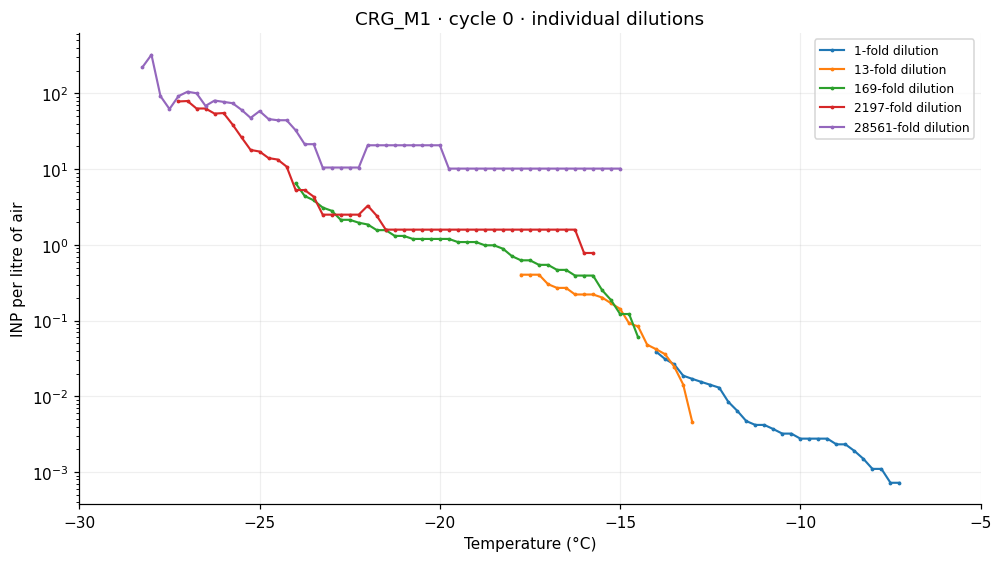

Log plots omit zero, negative and infinite concentrations; tables retain them.


In [8]:
def draw_spectrum(ax, frame, *, label, color, show_errors=False, linestyle="-", alpha=1):
    """Plot one selected curve; retain gaps where a log plot cannot show a value."""
    frame = frame.sort_values("temperature_C", ascending=False)
    visible = np.isfinite(frame.concentration) & (frame.concentration > 0)
    values = frame.concentration.where(visible)
    ax.plot(frame.temperature_C, values, color=color, linestyle=linestyle,
            marker=".", ms=3, lw=1.4, alpha=alpha, label=label)
    if show_errors:
        lower = frame.concentration - frame.lower_error
        upper = frame.concentration + frame.upper_error
        valid_band = visible & (lower > 0) & np.isfinite(lower) & np.isfinite(upper)
        ax.fill_between(frame.temperature_C, lower.where(valid_band), upper.where(valid_band),
                        color=color, alpha=0.13)


fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for index, (measurement_id, frame) in enumerate(individual_air.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False)):
    dilution = experiment.measurements[measurement_id].dilution
    draw_spectrum(ax, frame, label=f"{dilution:g}-fold dilution", color=f"C{index}")
ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · individual dilutions",
       xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.show()
print("Log plots omit zero, negative and infinite concentrations; tables retain them.")

## 5. Combine dilutions, separately within each sample, run and cycle

Automatic stitching uses the next dilution as the current measurement approaches
full freezing, requiring at least 3 unfrozen droplets. Each temperature uses one
dilution; its concentration and error bounds are copied without averaging. MLE
estimates one concentration from all eligible dilution counts at each temperature.
The limits in the next table apply **only to MLE**, not to automatic stitching.

`combine_dilutions()` receives the **frozen-fraction table**, which retains the
counts needed by both methods. Neither method combines different cycles.

`finalize_spectrum()` then applies the selected decrease rule to each combined
curve. Untrimmed curves stay in `combined_air_candidates` for inspection.

In [9]:
mle_controls = pd.DataFrame([
    {
        "measurement_id": measurement_id,
        "dilution": metadata.dilution,
        "temperatures_used": (
            f"<= {mle_method.temperature_eligibility_C[measurement_id]:g} °C"
            if measurement_id in mle_method.temperature_eligibility_C
            else "All temperatures"
        ),
        "action_count": mle_method.action_counts.get(measurement_id, 0),
    }
    for measurement_id, metadata in experiment.measurements.items()
])
mle_controls["likelihood_weight"] = 2 ** (-mle_controls.action_count / mle_method.action_weight_half_life)
mle_controls["mask_mode"] = mle_method.mask_mode
display(mle_controls)

stitched_suspension = inptk.combine_dilutions(
    fractions, experiment=experiment, method=automatic_method,
)
mle_suspension = inptk.combine_dilutions(
    fractions, experiment=experiment, method=mle_method,
)
stitched_air = inptk.convert_concentration(stitched_suspension, experiment.samples, basis="sampled_air")
mle_air = inptk.convert_concentration(mle_suspension, experiment.samples, basis="sampled_air")
combined_air_candidates = {"Automatic stitching": stitched_air, "MLE": mle_air}

if MANUAL_SWITCH_TEMPERATURES_C is not None:
    manual_suspension = inptk.combine_dilutions(
        fractions, experiment=experiment,
        method=inptk.ManualStitch(switch_temperatures_C=MANUAL_SWITCH_TEMPERATURES_C),
    )
    combined_air_candidates["Manual stitching"] = inptk.convert_concentration(
        manual_suspension, experiment.samples, basis="sampled_air",
    )

combined_air = {
    label: inptk.finalize_spectrum(table, decrease_policy=DECREASE_POLICY)
    for label, table in combined_air_candidates.items()
}

for label, table in combined_air.items():
    print(f"{label}: {len(table)} rows; warnings: {table.warnings or 'none'}")
    selected = table.select(**plot_selection).to_dataframe()
    display(selected.loc[selected.temperature_C.isin([-10, -15, -20, -25]), [
        "temperature_C", "concentration", "lower_error", "upper_error", "unit",
    ]])

,measurement_id,dilution,temperatures_used,action_count,likelihood_weight,mask_mode
0,Sample_0,1.0,All temperatures,0.0,1.000000,drop_rows
1,Sample_1,13.0,<= -10 °C,1.0,0.954842,drop_rows
2,Sample_2,169.0,<= -15 °C,2.0,0.911722,drop_rows
3,Sample_3,2197.0,<= -20 °C,3.0,0.870551,drop_rows
4,Sample_4,28561.0,<= -25 °C,4.0,0.831238,drop_rows


Automatic stitching: 187 rows; warnings: ['run_id=M1-base-rerun, sample_id=CRG_M1, cycle_id=0: final selection excluded 10 of 197 points using stop_at_decrease']


,temperature_C,concentration,lower_error,upper_error,unit
122,-10.0,0.002769,0.001558,0.002424,INP_per_L_air
142,-15.0,0.143033,0.067065,0.056645,INP_per_L_air
162,-20.0,1.199122,0.571173,0.595078,INP_per_L_air
182,-25.0,17.082683,8.303501,8.303501,INP_per_L_air


MLE: 122 rows; warnings: ['run_id=M1-base-rerun, sample_id=CRG_M1, cycle_id=0: final selection excluded 75 of 197 points using stop_at_decrease']


,temperature_C,concentration,lower_error,upper_error,unit


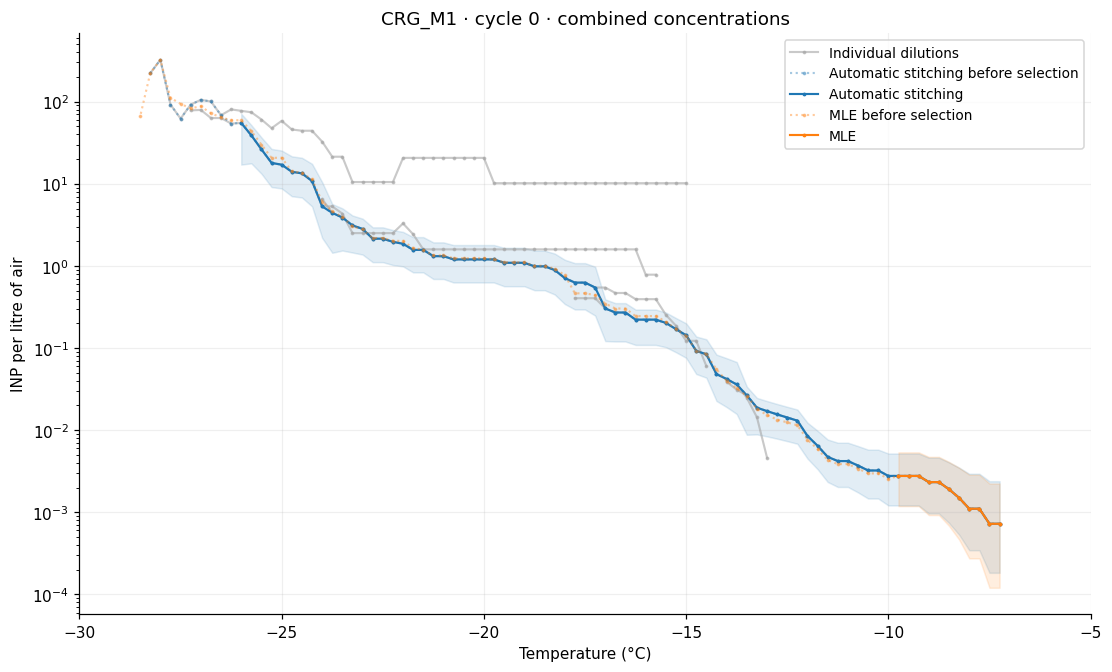

Shading uses each method's uncertainty calculation; intervals reaching zero are not shaded on the log axis.


In [10]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
for index, (measurement_id, frame) in enumerate(individual_air.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False)):
    draw_spectrum(ax, frame, label="Individual dilutions" if index == 0 else None,
                  color="0.65", alpha=0.6)
for index, (label, table) in enumerate(combined_air.items()):
    draw_spectrum(ax, combined_air_candidates[label].select(**plot_selection).to_dataframe(),
                  label=f"{label} before selection", color=f"C{index}", linestyle=":", alpha=0.4)
    draw_spectrum(ax, table.select(**plot_selection).to_dataframe(),
                  label=label, color=f"C{index}", show_errors=True)
ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · combined concentrations",
       xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.show()
print("Shading uses each method's uncertainty calculation; intervals reaching zero are not shaded on the log axis.")

## 6. Compare with the supplied OLAF final table

This is a visual comparison, not an assertion that the results should agree.
The reference uses a 0.5 °C grid; this notebook uses 0.25 °C. It is a final result
for this M1 experiment and has no cycle column. It is compared only with the
selected cycle, not duplicated across cycles or treated as repeated observations.
The reference's `lower_CI` and `upper_CI` columns are error widths in its INPs_L
export format.

,site,start_time,end_time,filter_color,sample_type,vol_air_filt,proportion_filter_used,vol_susp,treatment,notes,user,IS
0,CRG_M1,2025-08-12 13:00:00,2025-08-13 13:00:00,white,air,17829.1,1.0,10,base,none,Carson,IS1a


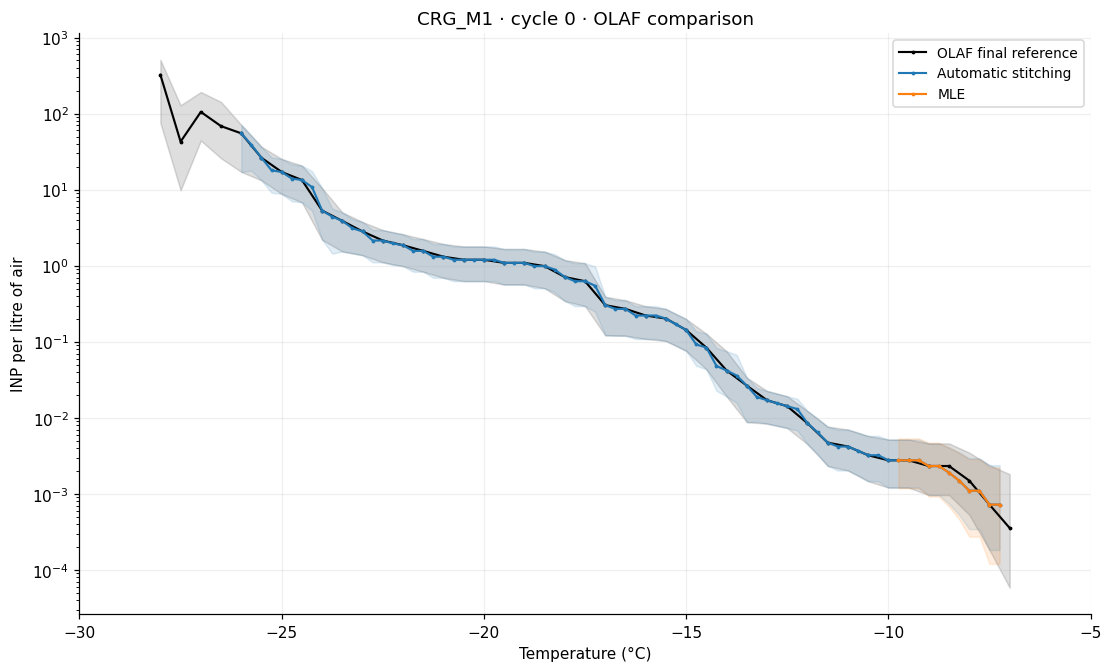

In [11]:
if OLAF_REFERENCE_PATH.is_file():
    reference_metadata = {}
    with OLAF_REFERENCE_PATH.open(encoding="utf-8") as stream:
        for header_index, line in enumerate(stream):
            if line.strip().startswith("degC,"):
                break
            if "=" in line:
                key, value = line.split("=", 1)
                reference_metadata[key.strip()] = value.strip()
        else:
            raise ValueError("OLAF reference is missing its degC header")
    reference = pd.read_csv(OLAF_REFERENCE_PATH, skiprows=header_index).rename(columns={
        "degC": "temperature_C", "INPS_L": "concentration",
        "lower_CI": "lower_error", "upper_CI": "upper_error",
    })
    for column in ("temperature_C", "concentration", "lower_error", "upper_error"):
        reference[column] = pd.to_numeric(reference[column], errors="raise")
    display(pd.DataFrame([reference_metadata]))
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    draw_spectrum(ax, reference, label="OLAF final reference", color="black", show_errors=True)
    for index, (label, table) in enumerate(combined_air.items()):
        draw_spectrum(ax, table.select(**plot_selection).to_dataframe(),
                      label=label, color=f"C{index}", show_errors=True)
    ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · OLAF comparison",
           xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.show()
else:
    print(f"Optional reference is unavailable: {OLAF_REFERENCE_PATH}")

## 7. The complete workflow uses the same steps

The convenience call below packages the imported experiment, frozen fractions,
individual curves, combined curve, settings, warnings and processing history.
The checks confirm that its results agree with the separate calls above.

In [12]:
result = inptk.analyze_concentration(
    experiment, dilution_method=automatic_method, output_basis="sampled_air",
    step_C=TEMPERATURE_STEP_C, temperature_method=TEMPERATURE_METHOD,
    temperature_tolerance_C=TEMPERATURE_TOLERANCE_C,
    decrease_policy=DECREASE_POLICY,
)
pd.testing.assert_frame_equal(result.frozen_fraction.to_dataframe(), fractions.to_dataframe())
pd.testing.assert_frame_equal(result.per_dilution.to_dataframe(), individual_suspension.to_dataframe())
pd.testing.assert_frame_equal(result.combined.to_dataframe(), stitched_suspension.to_dataframe())
pd.testing.assert_frame_equal(result.final.to_dataframe(), combined_air["Automatic stitching"].to_dataframe())
assert set(raw_counts.cycle_id) == set(result.final.to_dataframe().cycle_id)
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_sha256
print("Verified: separate steps match the full workflow; cycle labels preserved; input CSV unchanged.")

Verified: separate steps match the full workflow; cycle labels preserved; input CSV unchanged.


## 8. Optional export

Running this notebook does not create external result files by default. To save,
set `SAVE_RESULTS=True` and choose a new output folder. Existing folders are
rejected, so prior results cannot be overwritten. The saved analysis includes the
original source path and checksum, the excluded-row count, and the imported
observations that remain after that exclusion. The original source CSV retains
all observations, including the excluded rows.

In [13]:
SAVE_RESULTS = False
OUTPUT_DIR = DATA_PATH.parent / "inptk_m1_results"

if SAVE_RESULTS:
    OUTPUT_DIR.mkdir(exist_ok=False)
    result.save(OUTPUT_DIR / "automatic.inptk")
    fraction_df.to_csv(OUTPUT_DIR / "frozen_fractions.csv", index=False)
    individual_air.to_dataframe().to_csv(OUTPUT_DIR / "individual_dilutions_air.csv", index=False)
    pd.concat(
        [table.to_dataframe().assign(method=label) for label, table in combined_air.items()],
        ignore_index=True,
    ).to_csv(OUTPUT_DIR / "combined_methods_air.csv", index=False)
    excluded_rows.to_csv(OUTPUT_DIR / "excluded_zero_droplet_rows.csv", index=False)
    import json
    (OUTPUT_DIR / "method_history.json").write_text(
        json.dumps({label: table.history for label, table in combined_air.items()}, indent=2) + "\n"
    )
    print(f"Saved analysis and tables to {OUTPUT_DIR}")
else:
    print("External export is off. Set SAVE_RESULTS=True and choose a new folder when ready.")

External export is off. Set SAVE_RESULTS=True and choose a new folder when ready.
